In [22]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import linalg
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("=" * 60)
print("TVAR RANDOM WALK ANALYSIS")
print("Pure Adaptive TVAR | No Regime Switching")
print("=" * 60)

TVAR RANDOM WALK ANALYSIS
Pure Adaptive TVAR | No Regime Switching


In [23]:
df_raw = pd.read_csv('mesh_tvar_random_walk.csv')

print(f"Raw rows: {len(df_raw)}")
print(f"Duplicate window/node combos: {len(df_raw.groupby(['time_window','source_node']).filter(lambda x: len(x) > 1))}")

# Aggregate sub-flows: sum packet counts, mean everything else
df = df_raw.groupby(['time_window', 'source_node', 'route_id']).agg({
    'packets_sent':      'sum',
    'packets_lost':      'sum',
    'utilization':       'mean',
    'traffic_rate_kbps': 'mean',
    'avg_hops':          'mean'
}).reset_index()

# Recalculate loss rate from aggregated counts
df['loss_rate'] = (df['packets_lost'] / df['packets_sent']).fillna(0).clip(0, 1)

print(f"\nClean rows: {len(df)}")
print(f"Windows: {df['time_window'].nunique()}")
print(f"Routes:  {df['source_node'].nunique()}")
print(f"Duplicates remaining: {len(df.groupby(['time_window','source_node']).filter(lambda x: len(x) > 1))}")
print(f"\nLoss rate — Mean: {df['loss_rate'].mean():.4f} | Std: {df['loss_rate'].std():.4f}")
print(f"Traffic  — Min: {df['traffic_rate_kbps'].min():.1f} | Max: {df['traffic_rate_kbps'].max():.1f} kbps")


Raw rows: 4552
Duplicate window/node combos: 2652

Clean rows: 3226
Windows: 359
Routes:  9
Duplicates remaining: 0

Loss rate — Mean: 0.3793 | Std: 0.3339
Traffic  — Min: 300.0 | Max: 2014.5 kbps


✓ Saved: 01_loss_rate_per_node.png


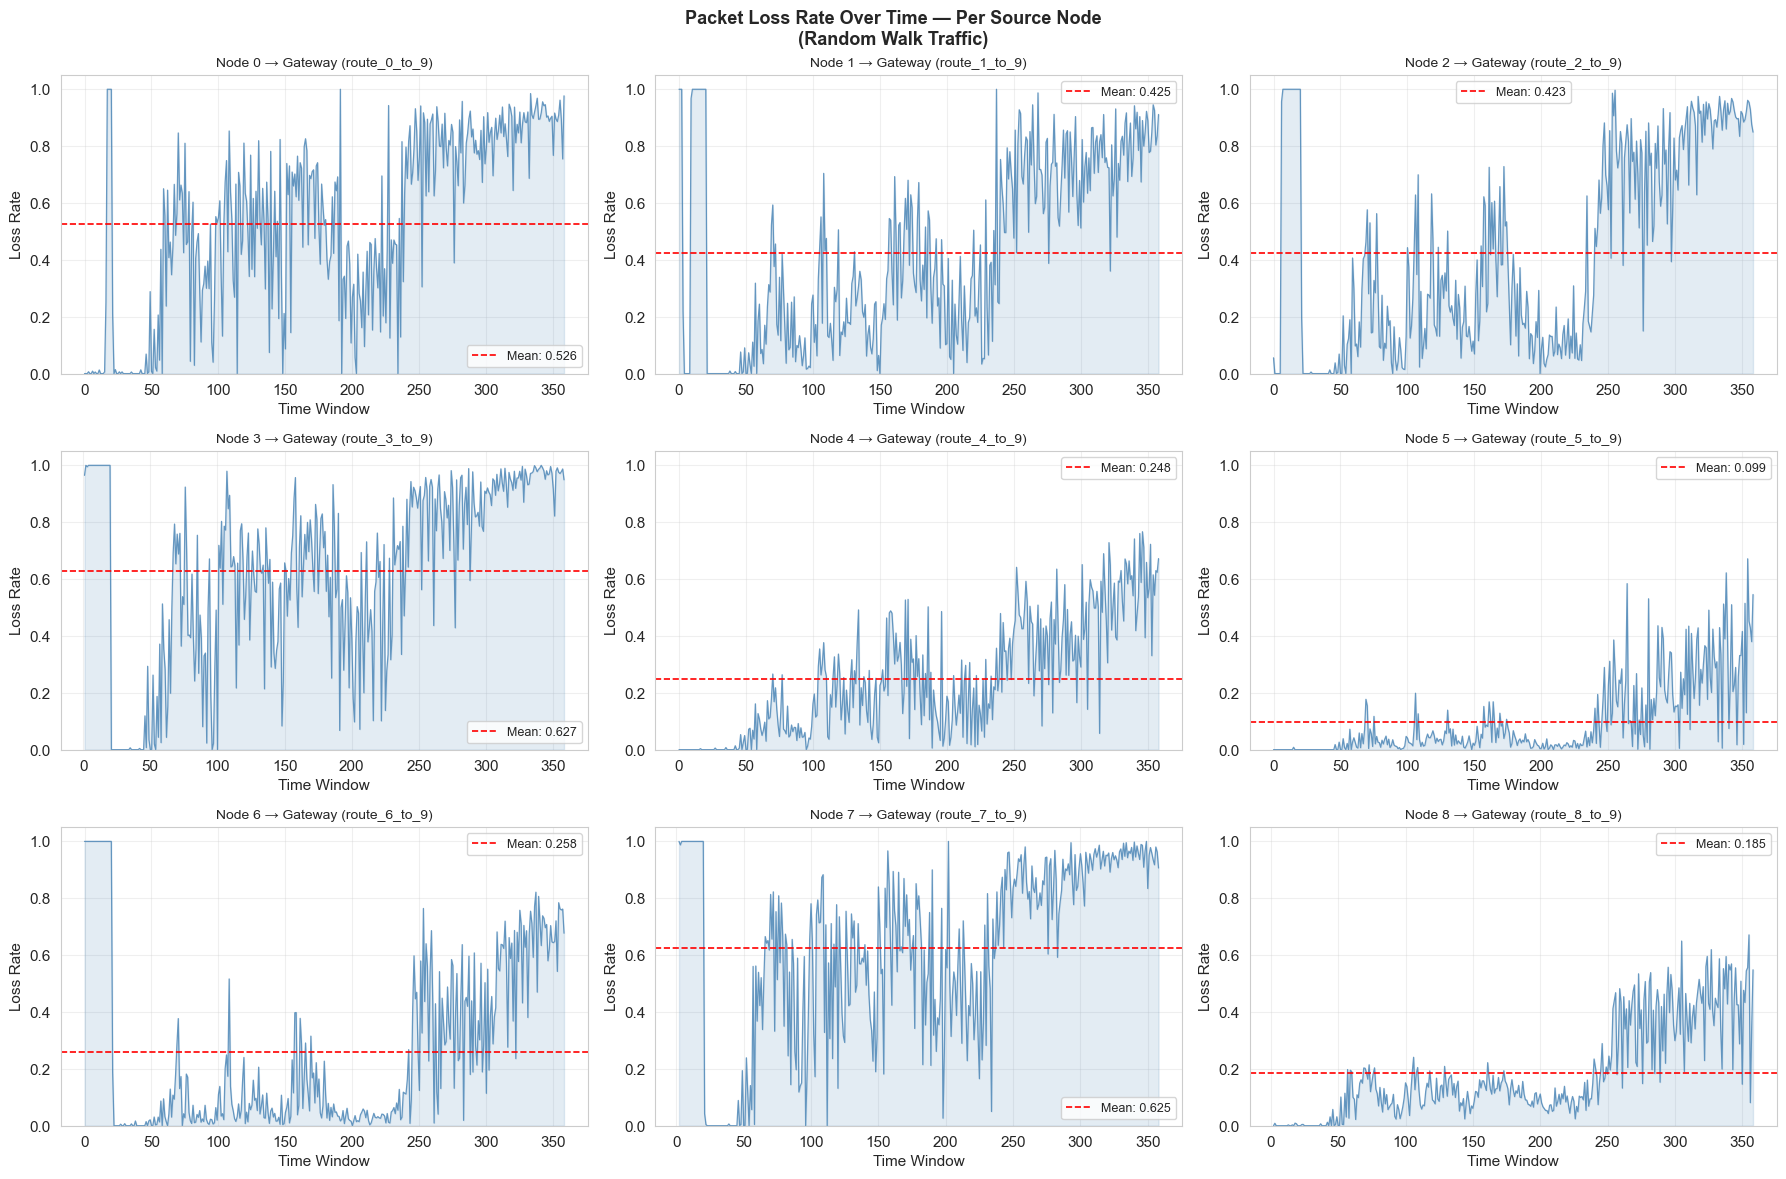

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, node in enumerate(sorted(df['source_node'].unique())):
    route_data = df[df['source_node'] == node].sort_values('time_window')
    ts = route_data['loss_rate'].values
    windows = route_data['time_window'].values

    ax = axes[idx]
    ax.plot(windows, ts, linewidth=0.9, color='steelblue', alpha=0.8)
    ax.axhline(np.mean(ts), color='red', linestyle='--', linewidth=1.2,
               label=f'Mean: {np.mean(ts):.3f}')
    ax.fill_between(windows, ts, alpha=0.15, color='steelblue')
    ax.set_title(f'Node {node} → Gateway (route_{node}_to_9)', fontsize=10)
    ax.set_xlabel('Time Window')
    ax.set_ylabel('Loss Rate')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Packet Loss Rate Over Time — Per Source Node\n(Random Walk Traffic)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_loss_rate_per_node.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_loss_rate_per_node.png")
plt.show()

✓ Saved: 03_loss_distribution.png


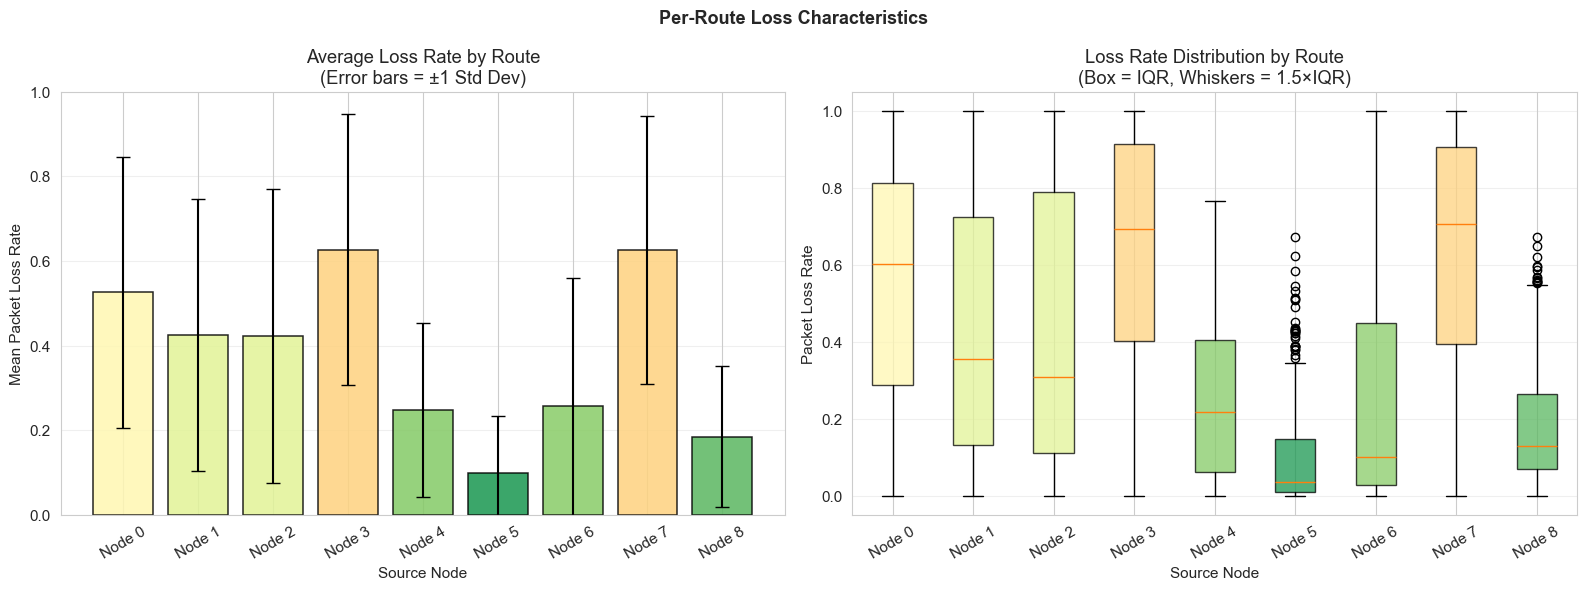

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — mean loss per node with std error bars
nodes = sorted(df['source_node'].unique())
means = [df[df['source_node'] == n]['loss_rate'].mean() for n in nodes]
stds  = [df[df['source_node'] == n]['loss_rate'].std()  for n in nodes]
hops  = [df[df['source_node'] == n]['avg_hops'].mean()  for n in nodes]

colors = plt.cm.RdYlGn_r([m for m in means])
bars = axes[0].bar([f'Node {n}' for n in nodes], means, yerr=stds,
                   capsize=5, color=colors, edgecolor='black', linewidth=1.1, alpha=0.85)
axes[0].set_xlabel('Source Node')
axes[0].set_ylabel('Mean Packet Loss Rate')
axes[0].set_title('Average Loss Rate by Route\n(Error bars = ±1 Std Dev)')
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=30)

# Box plot
df_plot = df.copy()
df_plot['Node'] = df_plot['source_node'].apply(lambda x: f'Node {x}')
node_order = [f'Node {n}' for n in nodes]
bp_data = [df[df['source_node'] == n]['loss_rate'].values for n in nodes]
bp = axes[1].boxplot(bp_data, labels=[f'Node {n}' for n in nodes],
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xlabel('Source Node')
axes[1].set_ylabel('Packet Loss Rate')
axes[1].set_title('Loss Rate Distribution by Route\n(Box = IQR, Whiskers = 1.5×IQR)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Per-Route Loss Characteristics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_loss_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_loss_distribution.png")
plt.show()

In [26]:
routes = {}
for node in sorted(df['source_node'].unique()):
    route_id = f'route_{node}_to_9'
    route_data = df[df['source_node'] == node].sort_values('time_window')
    ts = route_data['loss_rate'].values

    routes[route_id] = {
        'node':           node,
        'time_series':    ts,
        'traffic_series': route_data['traffic_rate_kbps'].values,
        'utilization':    route_data['utilization'].values,
        'windows':        route_data['time_window'].values,
        'length':         len(ts)
    }

print("=" * 60)
print("ROUTES DICTIONARY BUILT")
print("=" * 60)
for rid, rdata in routes.items():
    print(f"{rid}: {rdata['length']} windows | "
          f"mean loss={rdata['time_series'].mean():.3f} | "
          f"std={rdata['time_series'].std():.3f}")


ROUTES DICTIONARY BUILT
route_0_to_9: 359 windows | mean loss=0.526 | std=0.320
route_1_to_9: 359 windows | mean loss=0.425 | std=0.321
route_2_to_9: 359 windows | mean loss=0.423 | std=0.347
route_3_to_9: 358 windows | mean loss=0.627 | std=0.320
route_4_to_9: 359 windows | mean loss=0.248 | std=0.206
route_5_to_9: 359 windows | mean loss=0.099 | std=0.135
route_6_to_9: 359 windows | mean loss=0.258 | std=0.301
route_7_to_9: 357 windows | mean loss=0.625 | std=0.316
route_8_to_9: 357 windows | mean loss=0.185 | std=0.167


In [27]:
class TVARModelRLS:
    """
    TVAR with Recursive Least Squares estimation
    Forgetting factor λ controls how fast old data is discounted
    λ=1.0 → no forgetting (standard LS)
    λ=0.95 → aggressive forgetting (fast adaptation)
    λ=0.98 → moderate forgetting (recommended for random walk)
    """
    def __init__(self, order=2, lam=0.98):
        self.order = order
        self.lam = lam
        self.coefficients_history = []
        self._reset_rls()

    def _reset_rls(self):
        p = self.order
        # Initialise covariance matrix and coefficients
        self.P = np.eye(p) * 1000  # Large initial uncertainty
        self.phi = np.zeros(p)     # Initial coefficients

    def estimate_coefficients(self, y, n):
        if n < self.order:
            return np.zeros(self.order)

        # Build regressor vector [y(n-1), y(n-2)]
        x = y[n - self.order:n][::-1].reshape(-1, 1)
        target = y[n]

        # RLS update equations
        Px = self.P @ x
        gain = Px / (self.lam + float(x.T @ Px))

        # Prediction error
        error = target - float(x.T @ self.phi)

        # Update coefficients
        self.phi = self.phi + gain.flatten() * error

        # Update covariance with forgetting
        self.P = (self.P - gain @ x.T @ self.P) / self.lam

        return self.phi.copy()

    def predict_one_step(self, y, n):
        if n < self.order:
            return np.mean(y[:n+1]), np.zeros(self.order)

        phi = self.estimate_coefficients(y, n - 1)
        self.coefficients_history.append(phi.copy())

        past_values = y[n - self.order:n][::-1]
        y_hat = np.dot(phi, past_values)
        y_hat = np.clip(y_hat, 0.0, 1.0)
        return y_hat, phi

    def fit_predict(self, y_train):
        self._reset_rls()
        self.coefficients_history = []
        predictions = []

        for i in range(self.order, len(y_train)):
            y_hat, _ = self.predict_one_step(y_train, i)
            predictions.append(y_hat)

        return np.array(predictions)

In [28]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    LSTM_AVAILABLE = True
    print("✓ TensorFlow available — LSTM enabled")
except ImportError:
    LSTM_AVAILABLE = False
    print("⚠ TensorFlow not available — LSTM will be skipped")

TRAIN_RATIO = 0.70

def create_lstm_sequences(data, lookback=5):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

results_train = {}

print("=" * 60)
print("TRAINING ALL MODELS")
print("=" * 60)

for route_id, rdata in routes.items():
    ts = rdata['time_series']
    train_size = int(TRAIN_RATIO * len(ts))
    y_train = ts[:train_size]
    y_test  = ts[train_size:]

    route_results = {'train_size': train_size, 'test_size': len(y_test)}

    # --- TVAR ---
    tvar = TVARModelRLS(order=4, lam=0.98)
    tvar_preds_train = tvar.fit_predict(y_train)
    actual_train = y_train[2:2+len(tvar_preds_train)]
    tvar_rmse = np.sqrt(mean_squared_error(actual_train, tvar_preds_train))
    tvar_mae  = mean_absolute_error(actual_train, tvar_preds_train)
    route_results['tvar'] = {
        'model': tvar,
        'train_preds': tvar_preds_train,
        'train_rmse': tvar_rmse,
        'train_mae':  tvar_mae,
        'coeff_history': tvar.coefficients_history
    }

    # --- ARIMA ---
    try:
        arima_model = ARIMA(y_train, order=(2, 0, 1))
        arima_fit   = arima_model.fit()
        arima_preds = arima_fit.fittedvalues
        arima_preds = np.clip(arima_preds, 0, 1)
        arima_rmse  = np.sqrt(mean_squared_error(y_train, arima_preds))
        arima_mae   = mean_absolute_error(y_train, arima_preds)
        route_results['arima'] = {
            'model': arima_fit,
            'train_preds': arima_preds,
            'train_rmse': arima_rmse,
            'train_mae':  arima_mae
        }
    except Exception as e:
        print(f"  ARIMA failed for {route_id}: {e}")
        route_results['arima'] = {'train_rmse': 999, 'train_mae': 999}

    # --- LSTM ---
    if LSTM_AVAILABLE:
        try:
            scaler = MinMaxScaler()
            y_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
            lookback = 15
            X_lstm, y_lstm = create_lstm_sequences(y_scaled, lookback)
            X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

            lstm_model = Sequential([
                LSTM(32, input_shape=(lookback, 1), return_sequences=False),
                Dense(1, activation='sigmoid')
            ])
            lstm_model.compile(optimizer='adam', loss='mse')
            lstm_model.fit(X_lstm, y_lstm, epochs=50, batch_size=16, verbose=0)

            lstm_preds_scaled = lstm_model.predict(X_lstm, verbose=0).flatten()
            lstm_preds = scaler.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()
            lstm_preds = np.clip(lstm_preds, 0, 1)
            lstm_rmse = np.sqrt(mean_squared_error(y_lstm, lstm_preds_scaled))
            lstm_mae  = mean_absolute_error(y_lstm, lstm_preds_scaled)
            route_results['lstm'] = {
                'model': lstm_model,
                'scaler': scaler,
                'train_preds': lstm_preds,
                'train_rmse': lstm_rmse,
                'train_mae':  lstm_mae,
                'lookback': lookback
            }
        except Exception as e:
            print(f"  LSTM failed for {route_id}: {e}")
            route_results['lstm'] = {'train_rmse': 999, 'train_mae': 999}

    results_train[route_id] = route_results
    print(f"{route_id} | TVAR RMSE: {tvar_rmse:.4f} | "
          f"ARIMA RMSE: {route_results['arima']['train_rmse']:.4f}" +
          (f" | LSTM RMSE: {route_results['lstm']['train_rmse']:.4f}" if LSTM_AVAILABLE else ""))

# Summary table
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
tvar_rmses  = [results_train[r]['tvar']['train_rmse']  for r in results_train]
arima_rmses = [results_train[r]['arima']['train_rmse'] for r in results_train]
print(f"TVAR  Mean Train RMSE: {np.mean(tvar_rmses):.4f}")
print(f"ARIMA Mean Train RMSE: {np.mean(arima_rmses):.4f}")
if LSTM_AVAILABLE:
    lstm_rmses = [results_train[r]['lstm']['train_rmse'] for r in results_train]
    print(f"LSTM  Mean Train RMSE: {np.mean(lstm_rmses):.4f}")


✓ TensorFlow available — LSTM enabled
TRAINING ALL MODELS
route_0_to_9 | TVAR RMSE: 0.1937 | ARIMA RMSE: 0.2158 | LSTM RMSE: 0.2174
route_1_to_9 | TVAR RMSE: 0.1566 | ARIMA RMSE: 0.1872 | LSTM RMSE: 0.1556
route_2_to_9 | TVAR RMSE: 0.1217 | ARIMA RMSE: 0.1582 | LSTM RMSE: 0.1429
route_3_to_9 | TVAR RMSE: 0.1813 | ARIMA RMSE: 0.2018 | LSTM RMSE: 0.2006
route_4_to_9 | TVAR RMSE: 0.0799 | ARIMA RMSE: 0.0958 | LSTM RMSE: 0.1890
route_5_to_9 | TVAR RMSE: 0.0286 | ARIMA RMSE: 0.0352 | LSTM RMSE: 0.1281
route_6_to_9 | TVAR RMSE: 0.0954 | ARIMA RMSE: 0.1073 | LSTM RMSE: 0.1134
route_7_to_9 | TVAR RMSE: 0.1569 | ARIMA RMSE: 0.2093 | LSTM RMSE: 0.2023
route_8_to_9 | TVAR RMSE: 0.0317 | ARIMA RMSE: 0.0400 | LSTM RMSE: 0.1418

TRAINING SUMMARY
TVAR  Mean Train RMSE: 0.1162
ARIMA Mean Train RMSE: 0.1390
LSTM  Mean Train RMSE: 0.1657


In [29]:
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

results_test = {}

for route_id, rdata in routes.items():
    ts = rdata['time_series']
    train_size = results_train[route_id]['train_size']
    y_train = ts[:train_size]
    y_test  = ts[train_size:]

    route_test = {}

    # --- TVAR Test (rolling one-step-ahead) ---
    tvar_model = results_train[route_id]['tvar']['model']
    tvar_test_preds = []
    full_series = y_train.copy()

    for i in range(len(y_test)):
        n = len(full_series)
        y_hat, _ = tvar_model.predict_one_step(full_series, n)
        tvar_test_preds.append(y_hat)
        full_series = np.append(full_series, y_test[i])

    tvar_test_preds = np.array(tvar_test_preds)
    route_test['tvar'] = {
        'preds': tvar_test_preds,
        'rmse':  np.sqrt(mean_squared_error(y_test, tvar_test_preds)),
        'mae':   mean_absolute_error(y_test, tvar_test_preds)
    }

    # --- ARIMA Test ---
    try:
        arima_fit = results_train[route_id]['arima']['model']
        forecast  = arima_fit.forecast(steps=len(y_test))
        forecast  = np.clip(forecast, 0, 1)
        route_test['arima'] = {
            'preds': forecast,
            'rmse':  np.sqrt(mean_squared_error(y_test, forecast)),
            'mae':   mean_absolute_error(y_test, forecast)
        }
    except Exception:
        route_test['arima'] = {'preds': np.zeros(len(y_test)), 'rmse': 999, 'mae': 999}

    # --- LSTM Test ---
    if LSTM_AVAILABLE and results_train[route_id]['lstm']['train_rmse'] < 999:
        try:
            lstm_model = results_train[route_id]['lstm']['model']
            scaler     = results_train[route_id]['lstm']['scaler']
            lookback   = results_train[route_id]['lstm']['lookback']
            full_scaled = scaler.transform(ts.reshape(-1, 1)).flatten()
            X_test_seq, y_test_seq = create_lstm_sequences(
                full_scaled[train_size - lookback:], lookback)
            X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], lookback, 1)
            lstm_test_scaled = lstm_model.predict(X_test_seq, verbose=0).flatten()
            lstm_test_preds  = scaler.inverse_transform(
                lstm_test_scaled.reshape(-1, 1)).flatten()
            lstm_test_preds  = np.clip(lstm_test_preds, 0, 1)
            n = min(len(lstm_test_preds), len(y_test))
            route_test['lstm'] = {
                'preds': lstm_test_preds[:n],
                'rmse':  np.sqrt(mean_squared_error(y_test[:n], lstm_test_preds[:n])),
                'mae':   mean_absolute_error(y_test[:n], lstm_test_preds[:n])
            }
        except Exception as e:
            route_test['lstm'] = {'preds': np.zeros(len(y_test)), 'rmse': 999, 'mae': 999}

    route_test['y_test']     = y_test
    route_test['train_size'] = train_size
    results_test[route_id]   = route_test

    print(f"{route_id} | TVAR: {route_test['tvar']['rmse']:.4f} | "
          f"ARIMA: {route_test['arima']['rmse']:.4f}" +
          (f" | LSTM: {route_test['lstm']['rmse']:.4f}" if LSTM_AVAILABLE else ""))

# Summary
tvar_test_rmses  = [results_test[r]['tvar']['rmse']  for r in results_test]
arima_test_rmses = [results_test[r]['arima']['rmse'] for r in results_test]
print(f"\nTVAR  Mean Test RMSE:  {np.mean(tvar_test_rmses):.4f}")
print(f"ARIMA Mean Test RMSE:  {np.mean(arima_test_rmses):.4f}")
print(f"Improvement over ARIMA: {((np.mean(arima_test_rmses) - np.mean(tvar_test_rmses)) / np.mean(arima_test_rmses)) * 100:.1f}%")
if LSTM_AVAILABLE:
    lstm_test_rmses = [results_test[r]['lstm']['rmse'] for r in results_test]
    print(f"LSTM  Mean Test RMSE:  {np.mean(lstm_test_rmses):.4f}")
    print(f"TVAR vs LSTM: {((np.mean(lstm_test_rmses) - np.mean(tvar_test_rmses)) / np.mean(lstm_test_rmses)) * 100:.1f}%")


TEST SET EVALUATION
route_0_to_9 | TVAR: 0.1155 | ARIMA: 0.4399 | LSTM: 0.1988
route_1_to_9 | TVAR: 0.1438 | ARIMA: 0.4607 | LSTM: 0.3741
route_2_to_9 | TVAR: 0.1544 | ARIMA: 0.5511 | LSTM: 0.4450
route_3_to_9 | TVAR: 0.1120 | ARIMA: 0.3199 | LSTM: 0.2030
route_4_to_9 | TVAR: 0.1549 | ARIMA: 0.3107 | LSTM: 0.1925
route_5_to_9 | TVAR: 0.1658 | ARIMA: 0.2237 | LSTM: 0.1949
route_6_to_9 | TVAR: 0.1854 | ARIMA: 0.3281 | LSTM: 0.2470
route_7_to_9 | TVAR: 0.0716 | ARIMA: 0.3312 | LSTM: 0.2727
route_8_to_9 | TVAR: 0.1457 | ARIMA: 0.3152 | LSTM: 0.2375

TVAR  Mean Test RMSE:  0.1388
ARIMA Mean Test RMSE:  0.3645
Improvement over ARIMA: 61.9%
LSTM  Mean Test RMSE:  0.2628
TVAR vs LSTM: 47.2%


✓ Saved: 05_test_performance.png


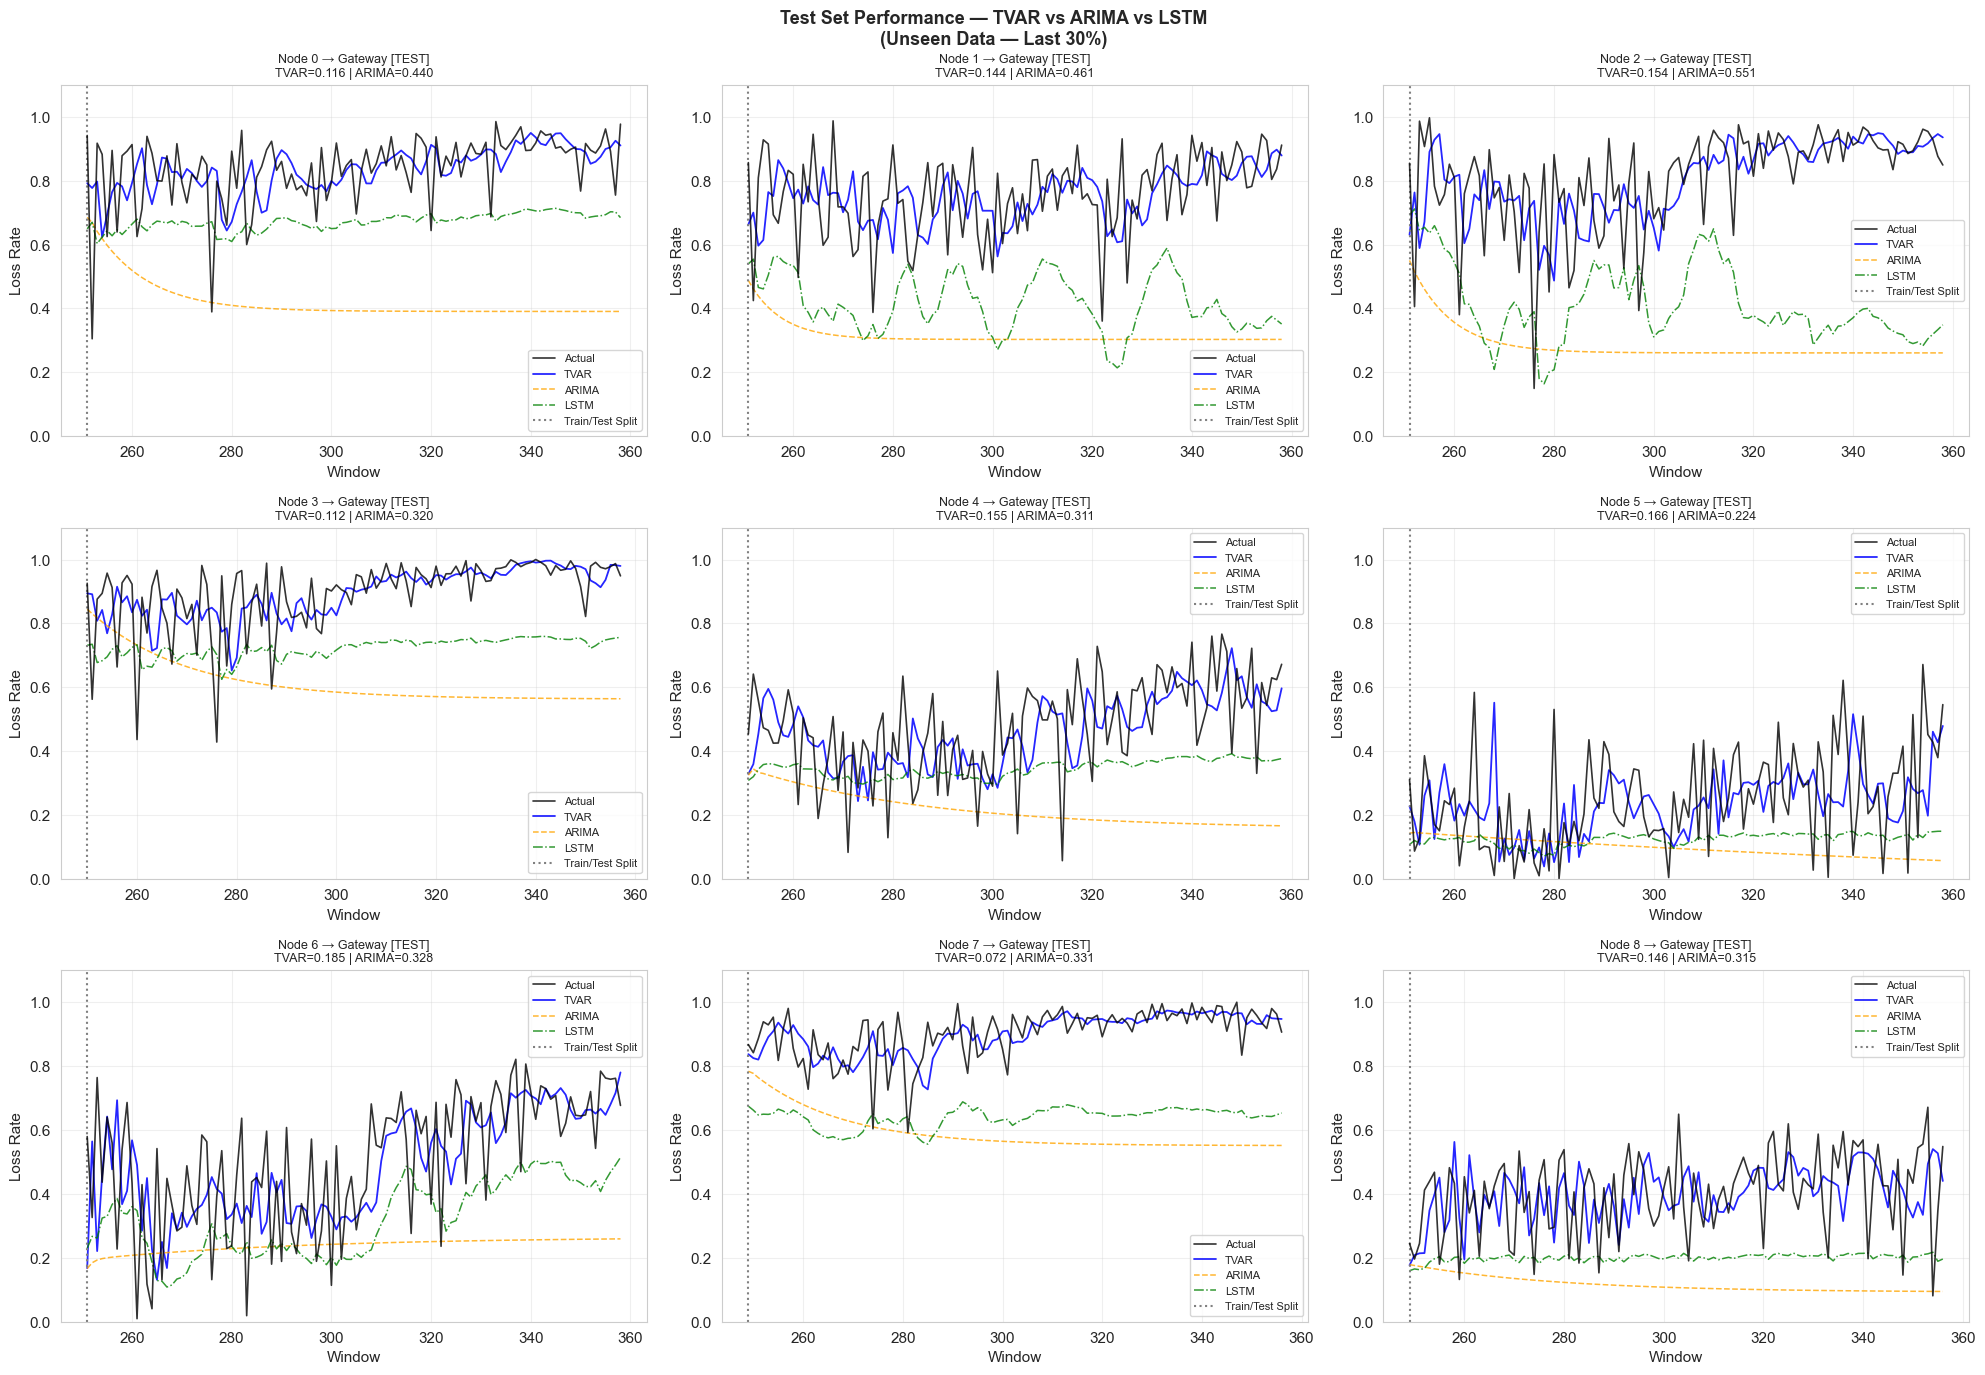

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, route_id in enumerate(results_test.keys()):
    y_test     = results_test[route_id]['y_test']
    train_size = results_test[route_id]['train_size']
    ax = axes[idx]

    x_test = range(train_size, train_size + len(y_test))

    ax.plot(x_test, y_test, color='black', linewidth=1.2,
            alpha=0.8, label='Actual', zorder=3)
    ax.plot(x_test, results_test[route_id]['tvar']['preds'],
            color='blue', linewidth=1.3, label='TVAR', alpha=0.85)

    if results_test[route_id]['arima']['rmse'] < 999:
        ax.plot(x_test, results_test[route_id]['arima']['preds'],
                color='orange', linewidth=1.1, linestyle='--', label='ARIMA', alpha=0.8)

    if LSTM_AVAILABLE and results_test[route_id]['lstm']['rmse'] < 999:
        n = len(results_test[route_id]['lstm']['preds'])
        ax.plot(range(train_size, train_size + n),
                results_test[route_id]['lstm']['preds'],
                color='green', linewidth=1.1, linestyle='-.', label='LSTM', alpha=0.8)

    ax.axvline(train_size, color='gray', linestyle=':', linewidth=1.5, label='Train/Test Split')

    node = routes[route_id]['node']
    tr = results_test[route_id]['tvar']['rmse']
    ar = results_test[route_id]['arima']['rmse']
    ax.set_title(f'Node {node} → Gateway [TEST]\nTVAR={tr:.3f} | ARIMA={ar:.3f}', fontsize=9)
    ax.set_xlabel('Window')
    ax.set_ylabel('Loss Rate')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Test Set Performance — TVAR vs ARIMA vs LSTM\n(Unseen Data — Last 30%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_test_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 05_test_performance.png")
plt.show()

✓ Saved: 06_rmse_comparison.png


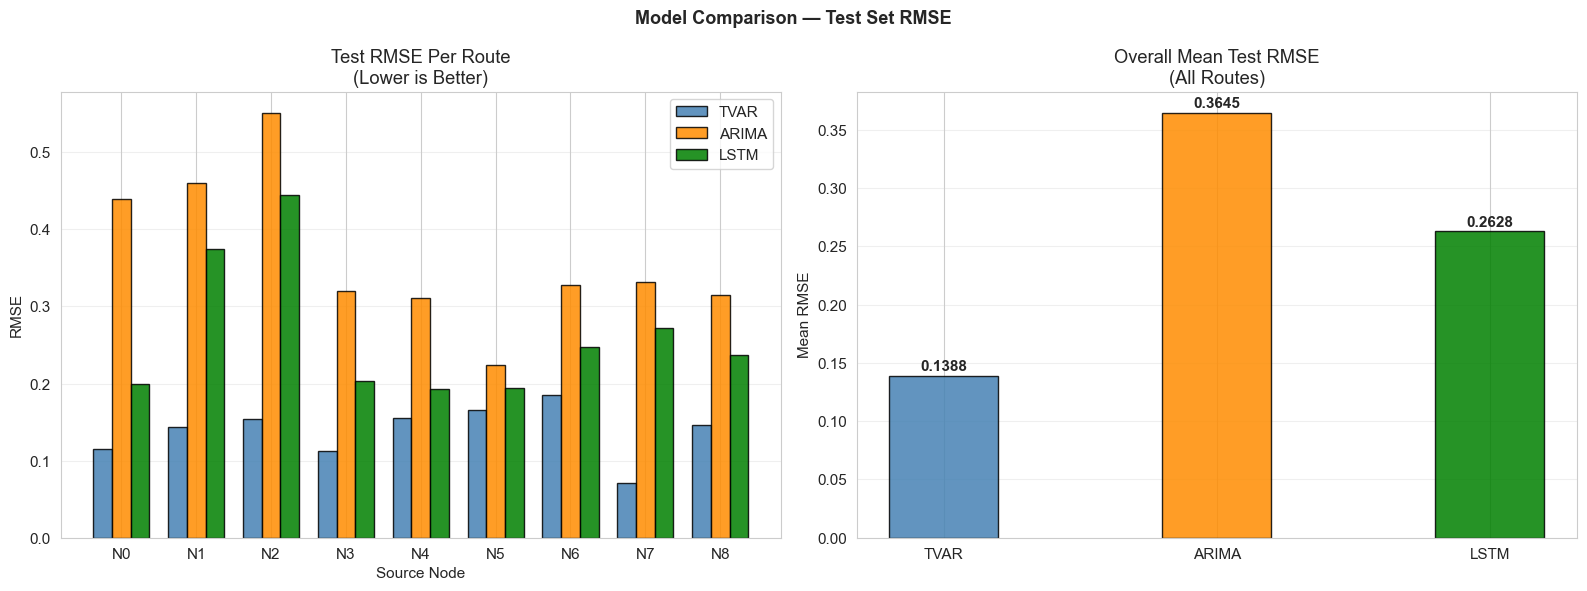

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

route_labels = [f"N{routes[r]['node']}" for r in results_test.keys()]
tvar_r  = [results_test[r]['tvar']['rmse']  for r in results_test]
arima_r = [results_test[r]['arima']['rmse'] for r in results_test]

x = np.arange(len(route_labels))
width = 0.25

# Test RMSE per route
axes[0].bar(x - width, tvar_r,  width, label='TVAR',  color='steelblue',  alpha=0.85, edgecolor='black')
axes[0].bar(x,         arima_r, width, label='ARIMA', color='darkorange', alpha=0.85, edgecolor='black')
if LSTM_AVAILABLE:
    lstm_r = [results_test[r]['lstm']['rmse'] for r in results_test]
    axes[0].bar(x + width, lstm_r, width, label='LSTM', color='green', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(route_labels)
axes[0].set_xlabel('Source Node')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Test RMSE Per Route\n(Lower is Better)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Overall mean comparison
models  = ['TVAR', 'ARIMA']
means   = [np.mean(tvar_r), np.mean(arima_r)]
colors  = ['steelblue', 'darkorange']
if LSTM_AVAILABLE:
    models.append('LSTM')
    means.append(np.mean(lstm_r))
    colors.append('green')

bars = axes[1].bar(models, means, color=colors, edgecolor='black', alpha=0.85, width=0.4)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean RMSE')
axes[1].set_title('Overall Mean Test RMSE\n(All Routes)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison — Test Set RMSE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_rmse_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 06_rmse_comparison.png")
plt.show()


In [32]:
print("=" * 60)
print("PDR SIMULATION: TVAR-GUIDED vs AODV BASELINE")
print("=" * 60)

def simulate_routing(routes, results_test, mode='aodv'):
    """
    Simulate routing decisions and compute PDR.
    AODV: selects route based on last observed loss rate (1-window lag)
    TVAR: selects route based on predicted next-window loss rate
    """
    all_windows = sorted(set(
        w for rdata in routes.values()
        for w in rdata['windows']
    ))

    train_size = list(results_test.values())[0]['train_size']
    test_windows = all_windows[train_size:]

    total_sent   = 0
    total_received = 0
    decisions    = []

    for t_idx, window in enumerate(test_windows):
        route_scores = {}

        for route_id, rdata in routes.items():
            ts = rdata['time_series']
            global_idx = train_size + t_idx

            if global_idx >= len(ts):
                continue

            if mode == 'aodv':
                # AODV: use last window's actual loss rate
                if global_idx > 0:
                    score = ts[global_idx - 1]
                else:
                    score = 0.5
            else:
                # TVAR: use model's predicted loss rate
                preds = results_test[route_id]['tvar']['preds']
                if t_idx < len(preds):
                    score = preds[t_idx]
                else:
                    score = ts[global_idx - 1] if global_idx > 0 else 0.5

            route_scores[route_id] = score

        if not route_scores:
            continue

        # Select route with lowest loss score
        best_route = min(route_scores, key=route_scores.get)
        actual_loss = routes[best_route]['time_series'][global_idx] if global_idx < len(routes[best_route]['time_series']) else 0.5

        # Simulate packet delivery
        pkts_sent = 100
        pkts_recv = int(pkts_sent * (1 - actual_loss))
        total_sent     += pkts_sent
        total_received += pkts_recv

        decisions.append({
            'window':     window,
            'best_route': best_route,
            'score':      route_scores[best_route],
            'actual_loss': actual_loss,
            'pdr_window': pkts_recv / pkts_sent
        })

    pdr = total_received / total_sent if total_sent > 0 else 0
    return pdr, pd.DataFrame(decisions)

aodv_pdr, aodv_decisions = simulate_routing(routes, results_test, mode='aodv')
tvar_pdr, tvar_decisions = simulate_routing(routes, results_test, mode='tvar')

print(f"\nAODV PDR:        {aodv_pdr * 100:.2f}%")
print(f"TVAR PDR:        {tvar_pdr * 100:.2f}%")
print(f"Improvement:     +{(tvar_pdr - aodv_pdr) * 100:.2f}% absolute")
print(f"Relative gain:   +{((tvar_pdr - aodv_pdr) / aodv_pdr) * 100:.1f}%")

# Route diversity
print(f"\nTVAR route diversity: {tvar_decisions['best_route'].nunique()} routes used")
print(f"AODV route diversity: {aodv_decisions['best_route'].nunique()} routes used")
print(f"\nRoute selection agreement: "
      f"{(tvar_decisions['best_route'].values == aodv_decisions['best_route'].values).mean()*100:.1f}% same route chosen")



PDR SIMULATION: TVAR-GUIDED vs AODV BASELINE

AODV PDR:        68.24%
TVAR PDR:        71.81%
Improvement:     +3.56% absolute
Relative gain:   +5.2%

TVAR route diversity: 4 routes used
AODV route diversity: 4 routes used

Route selection agreement: 68.5% same route chosen


✓ Saved: 07_pdr_comparison.png


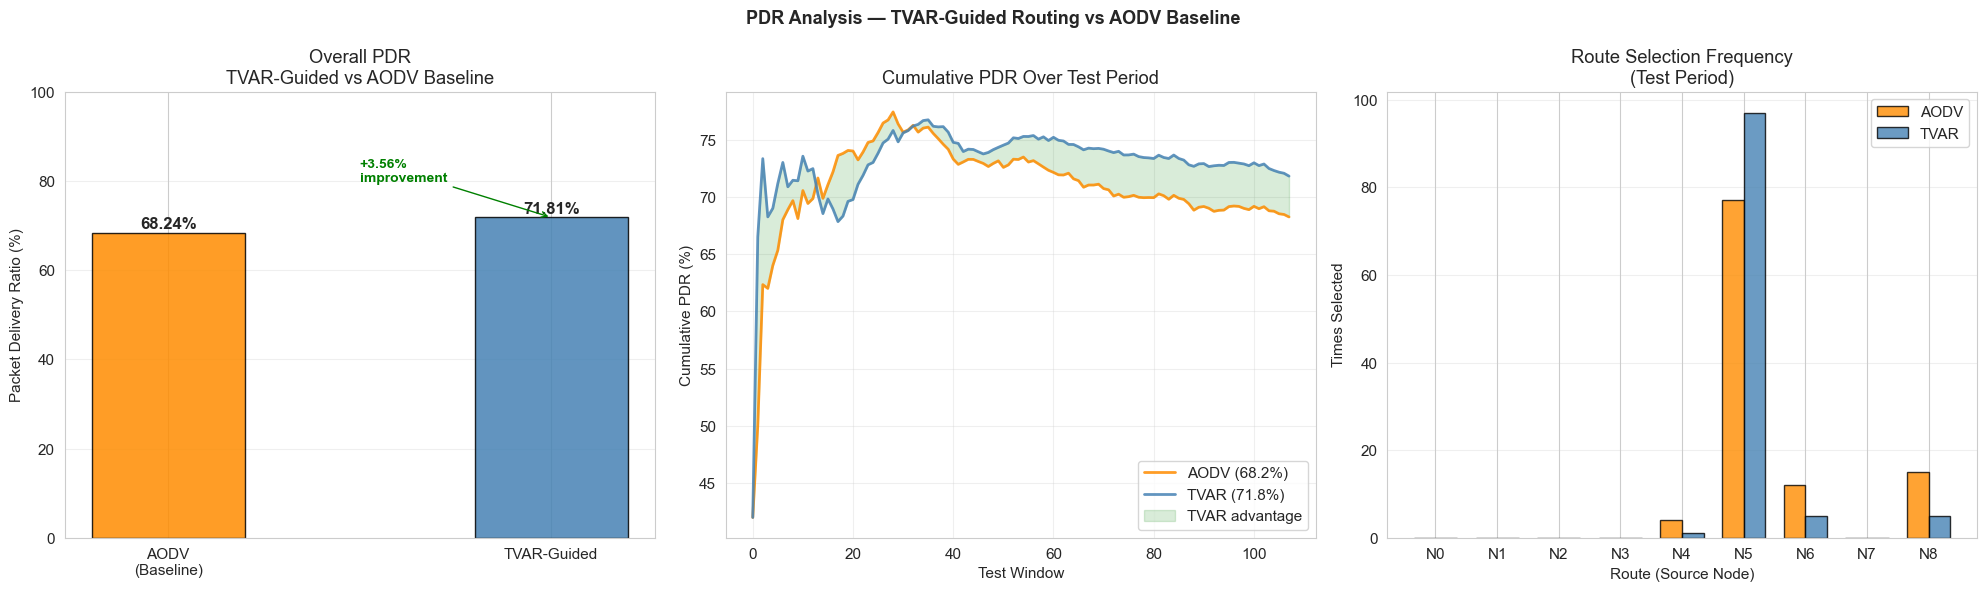


ANALYSIS COMPLETE
Figures saved: 01 through 07
TVAR Test RMSE improvement over ARIMA: 61.9%
TVAR PDR improvement over AODV: +3.56%


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1 — Overall PDR bar
models_pdr  = ['AODV\n(Baseline)', 'TVAR-Guided']
pdr_values  = [aodv_pdr * 100, tvar_pdr * 100]
bar_colors  = ['darkorange', 'steelblue']
bars = axes[0].bar(models_pdr, pdr_values, color=bar_colors,
                   edgecolor='black', alpha=0.85, width=0.4)
for bar, val in zip(bars, pdr_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Packet Delivery Ratio (%)')
axes[0].set_title('Overall PDR\nTVAR-Guided vs AODV Baseline')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3, axis='y')
diff = tvar_pdr - aodv_pdr
axes[0].annotate(f'+{diff*100:.2f}%\nimprovement',
                 xy=(1, tvar_pdr*100), xytext=(0.5, tvar_pdr*100 + 8),
                 fontsize=10, color='green', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='green'))

# Plot 2 — Cumulative PDR over test windows
aodv_cum = aodv_decisions['pdr_window'].expanding().mean() * 100
tvar_cum = tvar_decisions['pdr_window'].expanding().mean() * 100
axes[1].plot(aodv_cum.values, color='darkorange', linewidth=2,
             label=f'AODV ({aodv_pdr*100:.1f}%)', alpha=0.85)
axes[1].plot(tvar_cum.values, color='steelblue', linewidth=2,
             label=f'TVAR ({tvar_pdr*100:.1f}%)', alpha=0.85)
axes[1].fill_between(range(len(tvar_cum)),
                     aodv_cum.values, tvar_cum.values,
                     alpha=0.15, color='green', label='TVAR advantage')
axes[1].set_xlabel('Test Window')
axes[1].set_ylabel('Cumulative PDR (%)')
axes[1].set_title('Cumulative PDR Over Test Period')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Route selection frequency
tvar_freq = tvar_decisions['best_route'].value_counts()
aodv_freq = aodv_decisions['best_route'].value_counts()
all_routes = sorted(routes.keys())
t_counts = [tvar_freq.get(r, 0) for r in all_routes]
a_counts = [aodv_freq.get(r, 0) for r in all_routes]
xlabels  = [f"N{routes[r]['node']}" for r in all_routes]
x = np.arange(len(all_routes))
w = 0.35
axes[2].bar(x - w/2, a_counts, w, label='AODV', color='darkorange', alpha=0.8, edgecolor='black')
axes[2].bar(x + w/2, t_counts, w, label='TVAR', color='steelblue', alpha=0.8, edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(xlabels)
axes[2].set_xlabel('Route (Source Node)')
axes[2].set_ylabel('Times Selected')
axes[2].set_title('Route Selection Frequency\n(Test Period)')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('PDR Analysis — TVAR-Guided Routing vs AODV Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_pdr_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 07_pdr_comparison.png")
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"Figures saved: 01 through 07")
print(f"TVAR Test RMSE improvement over ARIMA: "
      f"{((np.mean(arima_test_rmses) - np.mean(tvar_test_rmses)) / np.mean(arima_test_rmses)) * 100:.1f}%")
print(f"TVAR PDR improvement over AODV: +{(tvar_pdr - aodv_pdr)*100:.2f}%")


In [38]:
# ============================================================
# DATA EXTRACTION — RANDOM WALK (AODV) — NOTEBOOK 3
# Corrected key mapping: tvar/arima/lstm nested dicts
# ============================================================
import json
import numpy as np

def to_list(arr):
    if arr is None:
        return []
    return [round(float(x), 6) for x in arr]

THRESHOLD     = 0.40
routes_export = {}

for route_id, route_data in results_test.items():
    actual      = routes[route_id]['time_series']
    traffic     = routes[route_id]['traffic_series']
    train_size  = int(route_data['train_size'])
    actual_test = route_data['y_test']

    # Nested prediction arrays
    tvar_preds  = route_data['tvar']['preds']
    arima_preds = route_data['arima']['preds']
    lstm_preds  = route_data['lstm']['preds']

    # Metrics — all nested under model key
    tvar_rmse  = float(route_data['tvar']['rmse'])
    tvar_mae   = float(route_data['tvar']['mae'])
    arima_rmse = float(route_data['arima']['rmse'])
    arima_mae  = float(route_data['arima']['mae'])
    lstm_rmse  = float(route_data['lstm']['rmse'])
    lstm_mae   = float(route_data['lstm']['mae'])

    # RLS has no rolling coefficient history
    phi1 = []
    phi2 = []

    # Early warning calculation
    early_warnings    = 0
    total_high_events = 0
    lead_times        = []

    for i in range(1, len(actual_test)):
        if actual_test[i] >= THRESHOLD and actual_test[i-1] < THRESHOLD:
            total_high_events += 1
            for lookback in range(1, 4):
                idx = i - lookback
                if idx >= 0 and idx < len(tvar_preds):
                    if tvar_preds[idx] >= THRESHOLD:
                        early_warnings += 1
                        lead_times.append(lookback)
                        break

    avg_lead = round(float(np.mean(lead_times)) if lead_times else 0, 2)

    routes_export[route_id] = {
        'node':          int(routes[route_id]['node']),
        'train_size':    int(train_size),
        'total_windows': int(len(actual)),
        'actual_full':   to_list(actual),
        'traffic_full':  to_list(traffic),
        'actual_test':   to_list(actual_test),
        'tvar_test':     to_list(tvar_preds),
        'arima_test':    to_list(arima_preds),
        'lstm_test':     to_list(lstm_preds),
        'phi1_history':  phi1,
        'phi2_history':  phi2,
        'metrics': {
            'tvar_rmse':  round(tvar_rmse,  6),
            'arima_rmse': round(arima_rmse, 6),
            'lstm_rmse':  round(lstm_rmse,  6),
            'tvar_mae':   round(tvar_mae,   6),
            'arima_mae':  round(arima_mae,  6),
            'lstm_mae':   round(lstm_mae,   6),
        },
        'early_warning': {
            'total_high_events': int(total_high_events),
            'tvar_early_count':  int(early_warnings),
            'avg_lead_windows':  float(avg_lead),
            'avg_lead_seconds':  float(round(avg_lead * 5, 1)),
            'threshold_used':    float(THRESHOLD)
        }
    }

# Network summary
network_summary = {
    'simulation':     'random_walk_aodv',
    'protocol':       'AODV',
    'traffic_type':   'random_walk',
    'total_windows':  int(len(routes[list(routes.keys())[0]]['time_series'])),
    'window_size_s':  5,
    'train_ratio':    0.70,
    'threshold_kbps': None,
    'nodes': {
        str(routes[rid]['node']): {
            'route_id':  rid,
            'mean_loss': round(float(np.mean(routes[rid]['time_series'])), 4),
            'std_loss':  round(float(np.std(routes[rid]['time_series'])),  4),
        }
        for rid in routes.keys()
    },
    'model_summary': {
        'tvar': {
            'mean_test_rmse': round(float(np.mean([routes_export[r]['metrics']['tvar_rmse']  for r in routes_export])), 4),
            'mean_test_mae':  round(float(np.mean([routes_export[r]['metrics']['tvar_mae']   for r in routes_export])), 4),
        },
        'arima': {
            'mean_test_rmse': round(float(np.mean([routes_export[r]['metrics']['arima_rmse'] for r in routes_export])), 4),
            'mean_test_mae':  round(float(np.mean([routes_export[r]['metrics']['arima_mae']  for r in routes_export])), 4),
        },
        'lstm': {
            'mean_test_rmse': round(float(np.mean([routes_export[r]['metrics']['lstm_rmse']  for r in routes_export])), 4),
            'mean_test_mae':  round(float(np.mean([routes_export[r]['metrics']['lstm_mae']   for r in routes_export])), 4),
        }
    }
}

# Topology
topology = {
    'nodes': [
        {'id': 0, 'x': 0,   'y': 0,   'type': 'source'},
        {'id': 1, 'x': 100, 'y': 0,   'type': 'source'},
        {'id': 2, 'x': 200, 'y': 0,   'type': 'source'},
        {'id': 3, 'x': 300, 'y': 0,   'type': 'source'},
        {'id': 4, 'x': 0,   'y': 100, 'type': 'source'},
        {'id': 5, 'x': 100, 'y': 100, 'type': 'source'},
        {'id': 6, 'x': 200, 'y': 100, 'type': 'source'},
        {'id': 7, 'x': 300, 'y': 100, 'type': 'source'},
        {'id': 8, 'x': 0,   'y': 200, 'type': 'source'},
        {'id': 9, 'x': 100, 'y': 200, 'type': 'gateway'},
    ],
    'links': [
        {'source': 0, 'target': 1}, {'source': 1, 'target': 2},
        {'source': 2, 'target': 3}, {'source': 4, 'target': 5},
        {'source': 5, 'target': 6}, {'source': 6, 'target': 7},
        {'source': 0, 'target': 4}, {'source': 1, 'target': 5},
        {'source': 2, 'target': 6}, {'source': 3, 'target': 7},
        {'source': 4, 'target': 8}, {'source': 5, 'target': 9},
        {'source': 8, 'target': 9},
    ]
}

# Behaviour timeline
def get_node_action(predicted_loss, threshold=0.40):
    if predicted_loss < threshold * 0.5:
        return {'status': 'Normal',   'action': 'Normal operation',         'colour': '#22c55e'}
    elif predicted_loss < threshold:
        return {'status': 'Watch',    'action': 'Monitor — mild increase',  'colour': '#eab308'}
    elif predicted_loss < threshold * 1.5:
        return {'status': 'Caution',  'action': 'Increase retransmissions', 'colour': '#f97316'}
    elif predicted_loss < threshold * 2:
        return {'status': 'High',     'action': 'Reduce transmission rate', 'colour': '#ef4444'}
    else:
        return {'status': 'Critical', 'action': 'Trigger route rediscovery','colour': '#7f1d1d'}

behaviour_export = {}
for route_id in routes_export.keys():
    test_preds  = routes_export[route_id]['tvar_test']
    actual_test = routes_export[route_id]['actual_test']
    timeline    = []
    for i, (pred, actual) in enumerate(zip(test_preds, actual_test)):
        action = get_node_action(pred)
        timeline.append({
            'window':         int(routes_export[route_id]['train_size'] + i),
            'predicted_loss': round(pred,   4),
            'actual_loss':    round(actual, 4),
            'error':          round(abs(pred - actual), 4),
            'status':         action['status'],
            'action':         action['action'],
            'colour':         action['colour']
        })
    behaviour_export[route_id] = timeline

# Write files
output_files = {
    'rw_dashboard_predictions.json': routes_export,
    'rw_dashboard_network.json':     network_summary,
    'rw_dashboard_topology.json':    topology,
    'rw_dashboard_behaviour.json':   behaviour_export
}

for filename, data in output_files.items():
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)
    size = len(json.dumps(data))
    print(f"✓ {filename:<40} ({size:,} bytes)")

print("\n" + "="*60)
print("EXPORT COMPLETE — Random Walk AODV — 4 files ready")
print("="*60)
print(f"Routes exported: {len(routes_export)}")
print(f"\nModel Performance Summary:")
for model in ['tvar', 'arima', 'lstm']:
    rmse = network_summary['model_summary'][model]['mean_test_rmse']
    mae  = network_summary['model_summary'][model]['mean_test_mae']
    print(f"  {model.upper():<8} RMSE: {rmse:.4f} | MAE: {mae:.4f}")
print(f"\nEarly Warning Summary:")
for route_id in routes_export:
    ew   = routes_export[route_id]['early_warning']
    node = routes_export[route_id]['node']
    print(f"  Node {node}: {ew['tvar_early_count']}/{ew['total_high_events']} "
          f"events predicted early | avg lead: {ew['avg_lead_seconds']}s")

✓ rw_dashboard_predictions.json            (100,857 bytes)
✓ rw_dashboard_network.json                (1,069 bytes)
✓ rw_dashboard_topology.json               (863 bytes)
✓ rw_dashboard_behaviour.json              (158,328 bytes)

EXPORT COMPLETE — Random Walk AODV — 4 files ready
Routes exported: 9

Model Performance Summary:
  TVAR     RMSE: 0.1388 | MAE: 0.1042
  ARIMA    RMSE: 0.3645 | MAE: 0.3359
  LSTM     RMSE: 0.2628 | MAE: 0.2374

Early Warning Summary:
  Node 0: 2/2 events predicted early | avg lead: 5.0s
  Node 1: 2/2 events predicted early | avg lead: 5.0s
  Node 2: 3/3 events predicted early | avg lead: 5.0s
  Node 3: 0/0 events predicted early | avg lead: 0.0s
  Node 4: 12/20 events predicted early | avg lead: 5.8s
  Node 5: 2/18 events predicted early | avg lead: 5.0s
  Node 6: 12/21 events predicted early | avg lead: 6.2s
  Node 7: 0/0 events predicted early | avg lead: 0.0s
  Node 8: 23/29 events predicted early | avg lead: 7.4s


In [35]:
first_key = list(results_test.keys())[0]
print(type(results_test))
print(first_key)
print(list(results_test[first_key].keys()))
print(f"tvar_preds length: {len(results_test[first_key].get('tvar_preds', []))}")
print(f"actual length: {len(results_test[first_key].get('actual', []))}")

<class 'dict'>
route_0_to_9
['tvar', 'arima', 'lstm', 'y_test', 'train_size']
tvar_preds length: 0
actual length: 0


In [36]:
first_key = list(results_test.keys())[0]
rd = results_test[first_key]

print(f"y_test length:  {len(rd['y_test'])}")
print(f"train_size:     {rd['train_size']}")
print(f"\nKeys inside tvar: {list(rd['tvar'].keys())}")
print(f"Keys inside arima: {list(rd['arima'].keys())}")
print(f"Keys inside lstm:  {list(rd['lstm'].keys())}")

y_test length:  108
train_size:     251

Keys inside tvar: ['preds', 'rmse', 'mae']
Keys inside arima: ['preds', 'rmse', 'mae']
Keys inside lstm:  ['preds', 'rmse', 'mae']
